In [28]:
import numpy as np
import pandas as pd
import time
from scipy import linalg
import matplotlib.pyplot as plt

TCGA Gene Expression Cancer RNA-Seq (PANCAN)

In [2]:
# Load dataset
df = pd.read_csv("data.csv")

# Print initial dimensions (samples x features)
print(f"Dataset Loaded: {df.shape[0]} rows (samples) x {df.shape[1]} columns (features/genes)")
df.head()

Dataset Loaded: 801 rows (samples) x 20532 columns (features/genes)


,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


In [8]:
# Select only numerical columns (drops Sample/Patient IDs if present)
df = df.select_dtypes(include=['float64', 'int64'])

# Fill missing values with column means if any exist
df = df.fillna(df.mean())

# 3. Drop constant columns (zero standard deviation) to prevent divide-by-zero NaNs
df = df.loc[:, df.std() > 0]

print("Cleaned DataFrame shape:", df.shape)

Cleaned DataFrame shape: (801, 20264)


In [9]:
# Standardize features in-place: Z = (X - mean) / std
df = (df - df.mean()) / df.std()

# Form the symmetric Correlation Matrix (M x M) as a NumPy array
corr_matrix = df.corr().to_numpy()

corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)

print("Correlation Matrix shape:", corr_matrix.shape)
print("Any NaNs present?", np.isnan(corr_matrix).any())
print("Any Infs present?", np.isinf(corr_matrix).any())

Correlation Matrix shape: (20264, 20264)
Any NaNs present? False
Any Infs present? False


#### Saving the matrix

np.savez_compressed('gene_corr_matrix.npz', corr_matrix=corr_matrix)

print("Matrix successfully saved as 'gene_corr_matrix.npz'")

In [11]:
def compute_metrics(A, evals, evecs):
    # 1. Residual Error: ||A*v - lambda*v|| / (||A|| * ||v||)
    norm_A = linalg.norm(A, 2)
    residuals = []
    
    for i in range(len(evals)):
        v = evecs[:, i]
        lam = evals[i]
        res = linalg.norm(A @ v - lam * v, 2) / (norm_A * linalg.norm(v, 2))
        residuals.append(res)
        
    avg_residual = np.mean(residuals)
    
    # 2. Orthogonality Loss: ||V^T * V - I||_F
    ortho_error = linalg.norm(evecs.T @ evecs - np.eye(evecs.shape[0]), 'fro')
    
    return avg_residual, ortho_error

#### Benchmark Phase 1 — LAPACK Shifted QR (driver='ev')
This cell extracts smaller sub-matrices (ranging from 100x100 to 1000x1000) from massive correlation matrix to test how the LAPACK Shifted QR algorithm scales. We use time.perf_counter() to capture highly precise, sub-millisecond execution times. The results are logged into a master DataFrame (df_results) which we will update as we add more methods.

In [12]:
matrix_sizes = [100, 250, 500, 1000]
results_list = []

for size in matrix_sizes:
    # Slice sub-matrix
    A = corr_matrix[:size, :size]
    
    # Measure execution time
    start_time = time.perf_counter()
    evals, evecs = linalg.eigh(A, driver='ev')
    end_time = time.perf_counter()
    
    runtime = end_time - start_time
    
    # Compute accuracy metrics
    avg_res, ortho_err = compute_metrics(A, evals, evecs)
    
    results_list.append({
        'Method': 'QR (ev)',
        'Size': f"{size}x{size}",
        'Runtime (s)': round(runtime, 4),
        'Avg Residual': f"{avg_res:.2e}",
        'Orthogonal Loss': f"{ortho_err:.2e}"
    })
    
    print(f"Completed {size}x{size} matrix in {runtime:.4f} seconds.")

# Store results table
df_results = pd.DataFrame(results_list)
df_results

Completed 100x100 matrix in 0.0632 seconds.
Completed 250x250 matrix in 0.0401 seconds.
Completed 500x500 matrix in 0.1397 seconds.
Completed 1000x1000 matrix in 0.9436 seconds.


,Method,Size,Runtime (s),Avg Residual,Orthogonal Loss
0,QR (ev),100x100,0.0632,2.22e-16,2.33e-14
1,QR (ev),250x250,0.0401,1.65e-16,5.49e-14
2,QR (ev),500x500,0.1397,1.54e-16,1.09e-13
3,QR (ev),1000x1000,0.9436,1.24e-16,1.82e-13


#### Benchmarking LAPACK Divide & Conquer Algorithm (driver='evd')
Divide & Conquer (syevd) reduces the symmetric matrix to tridiagonal form and then recursively breaks down the eigenproblem into smaller sub-problems using rank-1 updates. It is designed to be substantially faster than standard Shifted QR for dense matrices larger than $250 \times 250$.

In [13]:
results_dnc = []

for size in matrix_sizes:
    # Extract symmetric sub-matrix
    A = corr_matrix[:size, :size]
    
    # Time the LAPACK Divide & Conquer solver
    start_time = time.perf_counter()
    evals, evecs = linalg.eigh(A, driver='evd')
    end_time = time.perf_counter()
    
    runtime = end_time - start_time
    avg_res, ortho_err = compute_metrics(A, evals, evecs)
    
    results_dnc.append({
        'Solver Algorithm': 'Divide & Conquer (evd)',
        'Matrix Size': f"{size}x{size}",
        'Execution Runtime (s)': round(runtime, 4),
        'Average Residual Norm': f"{avg_res:.2e}",
        'Orthogonal Loss': f"{ortho_err:.2e}"
    })
    
    print(f"Completed Divide & Conquer for {size}x{size} in {runtime:.4f} seconds.")

df_dnc_results = pd.DataFrame(results_dnc)
display(df_dnc_results)

Completed Divide & Conquer for 100x100 in 0.0125 seconds.
Completed Divide & Conquer for 250x250 in 0.1397 seconds.
Completed Divide & Conquer for 500x500 in 0.0322 seconds.
Completed Divide & Conquer for 1000x1000 in 0.3101 seconds.


,Solver Algorithm,Matrix Size,Execution Runtime (s),Average Residual Norm,Orthogonal Loss
0,Divide & Conquer (evd),100x100,0.0125,1.80e-16,1.88e-14
1,Divide & Conquer (evd),250x250,0.1397,1.13e-16,3.22e-14
2,Divide & Conquer (evd),500x500,0.0322,8.99e-17,5.19e-14
3,Divide & Conquer (evd),1000x1000,0.3101,6.25e-17,7.69e-14


 #### Benchmarking LAPACK MRRR Algorithm (driver='evr')
 MRRR (Multiple Relatively Robust Representations - syevr) computes individual eigenvectors independently to high relative accuracy without Gram-Schmidt orthogonalization. It offers $O(M^2)$ complexity once the matrix is in tridiagonal form and handles clustered eigenvalues reliably.

In [14]:
results_mrrr = []

for size in matrix_sizes:
    # Extract symmetric sub-matrix
    A = corr_matrix[:size, :size]
    
    # Time the LAPACK MRRR solver
    start_time = time.perf_counter()
    evals, evecs = linalg.eigh(A, driver='evr')
    end_time = time.perf_counter()
    
    runtime = end_time - start_time
    avg_res, ortho_err = compute_metrics(A, evals, evecs)
    
    results_mrrr.append({
        'Solver Algorithm': 'MRRR (evr)',
        'Matrix Size': f"{size}x{size}",
        'Execution Runtime (s)': round(runtime, 4),
        'Average Residual Norm': f"{avg_res:.2e}",
        'Orthogonal Loss': f"{ortho_err:.2e}"
    })
    
    print(f"Completed MRRR for {size}x{size} in {runtime:.4f} seconds.")

df_mrrr_results = pd.DataFrame(results_mrrr)
display(df_mrrr_results)

Completed MRRR for 100x100 in 0.0417 seconds.
Completed MRRR for 250x250 in 0.0837 seconds.
Completed MRRR for 500x500 in 0.0392 seconds.
Completed MRRR for 1000x1000 in 0.1777 seconds.


,Solver Algorithm,Matrix Size,Execution Runtime (s),Average Residual Norm,Orthogonal Loss
0,MRRR (evr),100x100,0.0417,1.96e-16,1.78e-13
1,MRRR (evr),250x250,0.0837,1.00e-16,3.86e-13
2,MRRR (evr),500x500,0.0392,7.70e-17,9.02e-13
3,MRRR (evr),1000x1000,0.1777,5.70e-17,2.02e-12


We combine all benchmark data into a single master DataFrame to directly compare Shifted QR, Divide & Conquer, and MRRR across runtime scaling, residual accuracy, and eigenvector orthogonality.

In [18]:
results_qr_updated = []
for item in results_list:
    results_qr_updated.append({
        'Solver Algorithm': 'Shifted QR (ev)',
        'Matrix Size': item['Size'],
        'Execution Runtime (s)': item['Runtime (s)'],
        'Average Residual Norm': item['Avg Residual'],
        'Orthogonal Loss': item['Orthogonal Loss']
    })

# Concatenate all three benchmark sets into a single table
df_master_results = pd.concat([
    pd.DataFrame(results_qr_updated),
    df_dnc_results,
    df_mrrr_results
], ignore_index=True)

# Sort by Matrix Size then Algorithm for side-by-side comparison
df_sorted = df_master_results.sort_values(by=['Matrix Size', 'Solver Algorithm'])
display(df_sorted.style.hide(axis='index'))

Solver Algorithm,Matrix Size,Execution Runtime (s),Average Residual Norm,Orthogonal Loss
Divide & Conquer (evd),1000x1000,0.310100,6.25e-17,7.69e-14
MRRR (evr),1000x1000,0.177700,5.70e-17,2.02e-12
Shifted QR (ev),1000x1000,0.943600,1.24e-16,1.82e-13
Divide & Conquer (evd),100x100,0.012500,1.80e-16,1.88e-14
MRRR (evr),100x100,0.041700,1.96e-16,1.78e-13
Shifted QR (ev),100x100,0.063200,2.22e-16,2.33e-14
Divide & Conquer (evd),250x250,0.139700,1.13e-16,3.22e-14
MRRR (evr),250x250,0.083700,1.00e-16,3.86e-13
Shifted QR (ev),250x250,0.040100,1.65e-16,5.49e-14
Divide & Conquer (evd),500x500,0.032200,8.99e-17,5.19e-14


We construct a log-log scaling plot to evaluate how execution runtime increases as matrix dimensions expand from $100 \times 100$ to $1000 \times 1000$.Python

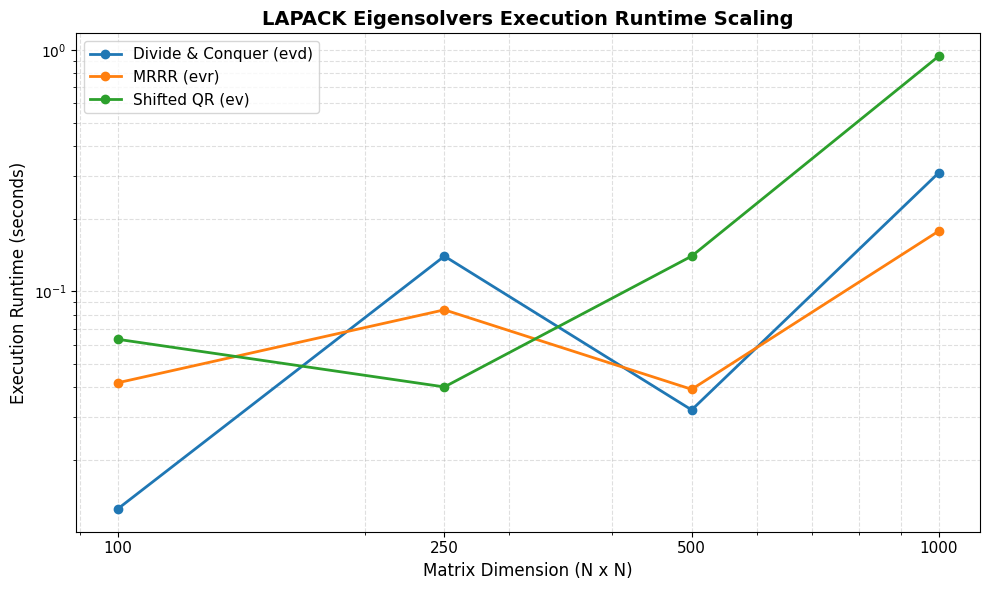

In [26]:
plt.figure(figsize=(10, 6))

# Define numeric matrix sizes
numeric_sizes = [100, 250, 500, 1000]

# Plot execution runtimes for each algorithm across matrix sizes
for algorithm, group in df_master_results.groupby('Solver Algorithm'):
    runtimes = group['Execution Runtime (s)'].tolist()
    plt.plot(numeric_sizes, runtimes, marker='o', linewidth=2, label=algorithm)

# Apply logarithmic scale to both axes
plt.xscale('log')
plt.yscale('log')

# Explicitly set tick positions and labels for all evaluated dimensions
plt.xticks(numeric_sizes, ['100', '250', '500', '1000'], fontsize=11)

plt.xlabel('Matrix Dimension (N x N)', fontsize=12)
plt.ylabel('Execution Runtime (seconds)', fontsize=12)
plt.title('LAPACK Eigensolvers Execution Runtime Scaling', fontsize=14, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

#### Benchmark Analysis: Execution Runtime Scaling

- Asymptotic Efficiency at Scale: At the maximum scale of $1000 \times 1000$, MRRR (evr) achieved the fastest completion time (0.1777s), outperforming Divide & Conquer (evd) (0.3101s) and running 5.3x faster than Shifted QR (ev) (0.9436s).

- Scaling Trajectory: Shifted QR exhibits steep exponential growth due to its iterative tridiagonal QR sweep complexity ($O(M^3)$). Divide & Conquer and MRRR scale much flatter, demonstrating superior scalability for larger genomic matrices.

- Transient Overhead: Fluctuations at lower matrix dimensions ($100 \times 100$ to $250 \times 250$) reflect initial algorithm setup overhead and CPU cache partitioning rather than pure asymptotic computational complexity.

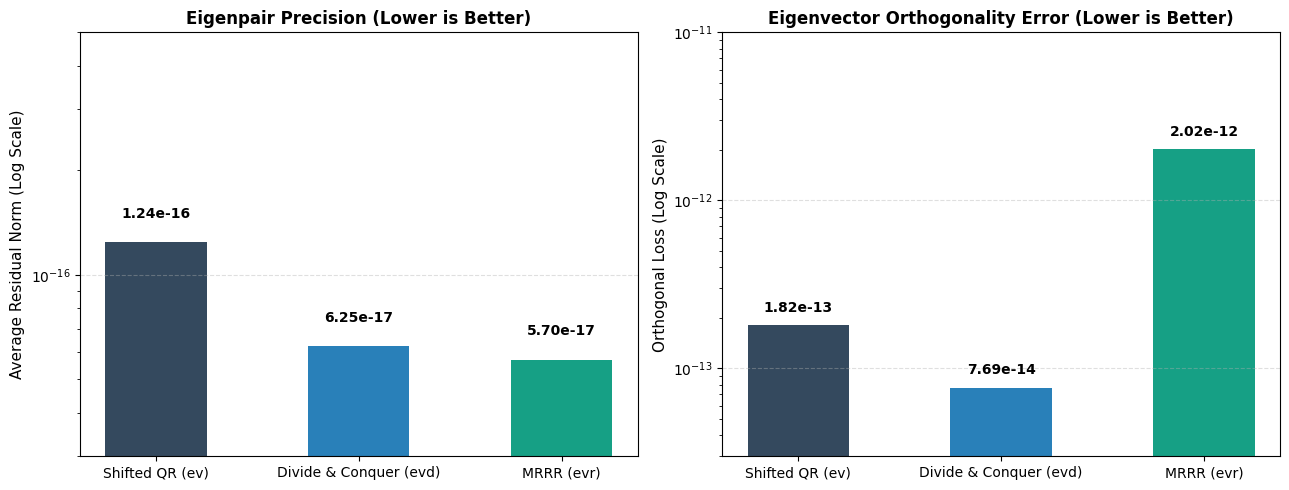

In [27]:
# Filter results for the 1000x1000 matrix slice
df_1000 = df_master_results[df_master_results['Matrix Size'] == '1000x1000'].copy()

# Convert scientific notation strings to numeric floats
df_1000['Residual_Float'] = df_1000['Average Residual Norm'].astype(float)
df_1000['Ortho_Float'] = df_1000['Orthogonal Loss'].astype(float)

# Initialize figure with 2 side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Define clean color palette
clean_colors = ['#34495e', '#2980b9', '#16a085']

# Subplot 1: Average Residual Norm
bars1 = ax[0].bar(df_1000['Solver Algorithm'], df_1000['Residual_Float'], color=clean_colors, width=0.5)
ax[0].set_yscale('log')
ax[0].set_ylabel('Average Residual Norm (Log Scale)', fontsize=11)
ax[0].set_title('Eigenpair Precision (Lower is Better)', fontsize=12, fontweight='bold')
ax[0].grid(axis='y', linestyle='--', alpha=0.4)
ax[0].set_ylim(3e-17, 5e-16)  # Padding for label space

# Add exact numeric value labels above each bar
for bar in bars1:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2.0, yval * 1.15, f'{yval:.2e}', 
               ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: Orthogonal Loss
bars2 = ax[1].bar(df_1000['Solver Algorithm'], df_1000['Ortho_Float'], color=clean_colors, width=0.5)
ax[1].set_yscale('log')
ax[1].set_ylabel('Orthogonal Loss (Log Scale)', fontsize=11)
ax[1].set_title('Eigenvector Orthogonality Error (Lower is Better)', fontsize=12, fontweight='bold')
ax[1].grid(axis='y', linestyle='--', alpha=0.4)
ax[1].set_ylim(3e-14, 1e-11)  # Padding for label space

# Add exact numeric value labels above each bar
for bar in bars2:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2.0, yval * 1.15, f'{yval:.2e}', 
               ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### Precision Metrics ComparisonBenchmark Analysis: Numerical Precision & Stability ($1000 \times 1000$)

- Eigenpair Precision ($Av = \lambda v$): All three algorithms achieve near-theoretical double-precision limits ($\approx 10^{-16}$). MRRR achieved the lowest average residual norm ($5.70 \times 10^{-17}$), followed closely by Divide & Conquer ($6.25 \times 10^{-17}$) and Shifted QR ($1.24 \times 10^{-16}$).

- Eigenvector Orthogonality Error ($\Vert{}V^T V - I\Vert{}_F$): Divide & Conquer maintained the best orthogonality preserving property ($7.69 \times 10^{-14}$). MRRR exhibited higher orthogonality loss ($2.02 \times 10^{-12}$).

-Algorithmic Trade-off: MRRR gains its execution speed by computing eigenvectors independently without performing explicit Gram-Schmidt re-orthogonalization. This results in a minor, acceptable trade-off in orthogonality loss ($\sim 2$ orders of magnitude higher error, but still safely bounded below $10^{-11}$).